# Frage 4 – VAT Reduction vs. Inflation 2021

**Research question:**  
How did the temporary VAT reduction in Germany (July–December 2020) affect retailer price-setting behaviour, and to what extent was this effect offset by the inflation surge in 2021?



In [15]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## 1. Konfiguration

Hier legen wir Dateipfade und wichtige Zeiträume fest.


In [16]:
BASE_DIR = Path(".")

# Erwartete Input-Dateien
BUTTER_FILE = BASE_DIR / "eurostat_butter_cpi.json"
PPI_FILE = BASE_DIR / "eurostat_ppi_dairy.json"

# Policy-Zeitraum: temporäre Mehrwertsteuersenkung
VAT_START = pd.Timestamp("2020-07-01")
VAT_END = pd.Timestamp("2020-12-31")

# Vergleichszeitraum: Inflationsjahr 2021
INFLATION_2021_START = pd.Timestamp("2021-01-01")
INFLATION_2021_END = pd.Timestamp("2021-12-31")

# Analysefenster
ANALYSIS_START = pd.Timestamp("2019-01-01")
ANALYSIS_END = pd.Timestamp("2021-12-31")


## 2. Funktion: Eurostat-JSON in DataFrame umwandeln


In [17]:
def eurostat_json_to_df(file_path: Path, value_name: str) -> pd.DataFrame:
    """
    Liest eine Eurostat-/Destatis-ähnliche JSON-Datei ein und wandelt sie
    in einen DataFrame mit Monatsdatum und Wertespalte um.
    """
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    time_index = data["dimension"]["time"]["category"]["index"]
    time_labels = data["dimension"]["time"]["category"]["label"]
    values = data["value"]

    rows = []

    for label_key, position in time_index.items():
        position_str = str(position)

        # Nur echte Messwerte übernehmen
        if position_str in values:
            rows.append(
                {
                    "datum_raw": time_labels[label_key],
                    value_name: values[position_str],
                }
            )

    df = pd.DataFrame(rows)

    # "2020M07" -> "2020-07"
    df["datum"] = pd.to_datetime(
        df["datum_raw"].str.replace("M", "-", regex=False),
        format="%Y-%m",
        errors="coerce",
    )

    df.drop(columns=["datum_raw"], inplace=True)

    # Werte sicher in numerisches Format umwandeln
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")

    return df


## 3. Funktion: Zeitreihe bereinigen




In [18]:
def clean_time_series(
    df: pd.DataFrame,
    value_column: str,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
) -> pd.DataFrame:
    """
    Bereinigt eine monatliche Zeitreihe.
    """
    cleaned_df = df.copy()

    # Ungültige Datumswerte entfernen
    cleaned_df = cleaned_df.dropna(subset=["datum"])

    # Doppelte Monate entfernen
    cleaned_df = cleaned_df.drop_duplicates(subset=["datum"], keep="last")

    # Chronologisch sortieren
    cleaned_df = cleaned_df.sort_values("datum").reset_index(drop=True)

    # Nur gewünschter Analysezeitraum
    cleaned_df = cleaned_df[
        (cleaned_df["datum"] >= start_date) & (cleaned_df["datum"] <= end_date)
    ].copy()

    return cleaned_df


## 4. Funktionen: Features, Merge und Qualitätsbericht


In [19]:
def add_policy_and_period_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ergänzt Policy Dummy, Jahr, Monat und Periodenlabels.
    """
    enriched_df = df.copy()

    enriched_df["mwst_dummy"] = (
        (enriched_df["datum"] >= VAT_START) & (enriched_df["datum"] <= VAT_END)
    ).astype(int)

    enriched_df["year"] = enriched_df["datum"].dt.year
    enriched_df["month"] = enriched_df["datum"].dt.month

    enriched_df["periode"] = "other"
    enriched_df.loc[
        (enriched_df["datum"] >= pd.Timestamp("2019-01-01"))
        & (enriched_df["datum"] <= pd.Timestamp("2020-06-30")),
        "periode",
    ] = "before_vat"
    enriched_df.loc[
        (enriched_df["datum"] >= VAT_START)
        & (enriched_df["datum"] <= VAT_END),
        "periode",
    ] = "during_vat"
    enriched_df.loc[
        (enriched_df["datum"] >= INFLATION_2021_START)
        & (enriched_df["datum"] <= INFLATION_2021_END),
        "periode",
    ] = "inflation_2021"

    return enriched_df


def merge_series(butter_df: pd.DataFrame, ppi_df: pd.DataFrame) -> pd.DataFrame:
    """
    Verbindet Butter-CPI und Dairy-PPI über das Monatsdatum.
    """
    merged_df = pd.merge(butter_df, ppi_df, on="datum", how="inner")
    merged_df = merged_df.sort_values("datum").reset_index(drop=True)

    # Monatliche Veränderung
    merged_df["butter_mom_pct"] = merged_df["butter_cpi"].pct_change() * 100
    merged_df["dairy_ppi_mom_pct"] = merged_df["dairy_ppi"].pct_change() * 100

    # Veränderung zum Vorjahresmonat
    merged_df["butter_yoy_pct"] = merged_df["butter_cpi"].pct_change(12) * 100
    merged_df["dairy_ppi_yoy_pct"] = merged_df["dairy_ppi"].pct_change(12) * 100

    # Abstand zwischen Retail- und Produktionsindex
    merged_df["index_gap"] = merged_df["butter_cpi"] - merged_df["dairy_ppi"]

    return merged_df


def print_data_quality_report(df: pd.DataFrame) -> None:
    """
    Zeigt einen kompakten Datenqualitätsbericht.
    """
    print("=" * 70)
    print("DATA QUALITY REPORT")
    print("=" * 70)
    print(f"Number of rows: {len(df)}")
    print(f"Date range: {df['datum'].min().date()} to {df['datum'].max().date()}")
    print("\nMissing values per column:")
    print(df.isna().sum())
    print("\nDuplicate dates:", int(df["datum"].duplicated().sum()))
    print("=" * 70)


## 5. Funktionen: Kennzahlen und Interpretation


In [20]:
def get_single_value(df: pd.DataFrame, date_string: str, column_name: str) -> float:
    """
    Holt den Wert einer bestimmten Variable für einen bestimmten Monat.
    """
    target_date = pd.Timestamp(date_string)
    subset = df.loc[df["datum"] == target_date, column_name]

    if subset.empty:
        raise ValueError(
            f"Missing required observation for {date_string} in column {column_name}."
        )

    return float(subset.iloc[0])


def calculate_phase_effects(df: pd.DataFrame) -> dict:
    """
    Berechnet den Effekt der VAT-Phase und den Gegeneffekt im Jahr 2021.
    """
    vat_start_value = get_single_value(df, "2020-07-01", "butter_cpi")
    vat_end_value = get_single_value(df, "2020-12-01", "butter_cpi")

    inflation_2021_start_value = get_single_value(df, "2021-01-01", "butter_cpi")
    inflation_2021_end_value = get_single_value(df, "2021-12-01", "butter_cpi")

    vat_effect_pct = ((vat_end_value - vat_start_value) / vat_start_value) * 100
    inflation_2021_pct = (
        (inflation_2021_end_value - inflation_2021_start_value)
        / inflation_2021_start_value
    ) * 100

    offset_ratio = np.nan
    if vat_effect_pct != 0:
        offset_ratio = inflation_2021_pct / abs(vat_effect_pct)

    return {
        "vat_start_value": vat_start_value,
        "vat_end_value": vat_end_value,
        "vat_effect_pct": vat_effect_pct,
        "inflation_2021_start_value": inflation_2021_start_value,
        "inflation_2021_end_value": inflation_2021_end_value,
        "inflation_2021_pct": inflation_2021_pct,
        "offset_ratio": offset_ratio,
    }


def print_interpretation(results: dict) -> None:
    """
    Gibt eine leicht erklärbare Interpretation aus.
    """
    vat_effect_pct = results["vat_effect_pct"]
    inflation_2021_pct = results["inflation_2021_pct"]
    offset_ratio = results["offset_ratio"]

    print("\n" + "=" * 70)
    print("QUESTION 4 – INTERPRETATION")
    print("=" * 70)
    print(f"Butter CPI during VAT phase (Jul–Dec 2020): {vat_effect_pct:.2f}%")
    print(f"Butter CPI during inflation year 2021:      {inflation_2021_pct:.2f}%")

    if vat_effect_pct < 0:
        print(
            "Interpretation: Retail prices fell during the VAT reduction phase, "
            "which suggests at least partial pass-through to consumers."
        )
    elif vat_effect_pct > 0:
        print(
            "Interpretation: Retail prices still increased during the VAT phase, "
            "which suggests weak or no visible consumer pass-through."
        )
    else:
        print("Interpretation: Retail prices were flat during the VAT phase.")

    if np.isnan(offset_ratio):
        print("Offset ratio cannot be calculated because the VAT effect was zero.")
    elif offset_ratio > 1:
        print("The 2021 inflation surge more than offset the earlier VAT-phase effect.")
    else:
        print("The 2021 inflation surge offset only part of the earlier VAT-phase effect.")

    print("=" * 70)


## 6. Funktionen: Visualisierungen



In [21]:
def plot_line_chart(df: pd.DataFrame) -> None:
    plt.figure(figsize=(12, 6))
    plt.plot(df["datum"], df["butter_cpi"], linewidth=2, label="Butter CPI")
    plt.plot(df["datum"], df["dairy_ppi"], linewidth=2, label="Dairy PPI")

    plt.axvspan(VAT_START, VAT_END, alpha=0.15, label="VAT reduction period")
    plt.axvspan(
        INFLATION_2021_START,
        INFLATION_2021_END,
        alpha=0.08,
        label="Inflation year 2021",
    )

    plt.title("Chart 1: Butter CPI and Dairy PPI over Time")
    plt.xlabel("Date")
    plt.ylabel("Index value")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_bar_chart(df: pd.DataFrame) -> None:
    yoy_df = df.dropna(subset=["butter_yoy_pct"]).copy()

    plt.figure(figsize=(12, 6))
    plt.bar(yoy_df["datum"], yoy_df["butter_yoy_pct"])

    plt.axhline(0, linewidth=1)
    plt.title("Chart 2: Year-over-Year Change in Butter CPI")
    plt.xlabel("Date")
    plt.ylabel("YoY change in %")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_boxplot(df: pd.DataFrame) -> None:
    boxplot_df = df.dropna(subset=["butter_mom_pct"]).copy()

    periods = ["before_vat", "during_vat", "inflation_2021"]
    data = [
        boxplot_df.loc[boxplot_df["periode"] == period, "butter_mom_pct"].values
        for period in periods
    ]

    plt.figure(figsize=(10, 6))
    plt.boxplot(data, tick_labels=periods)

    plt.axhline(0, linewidth=1)
    plt.title("Chart 3: Monthly Butter CPI Changes by Period")
    plt.xlabel("Period")
    plt.ylabel("MoM change in %")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_scatter_chart(df: pd.DataFrame) -> None:
    scatter_df = df.dropna(subset=["butter_cpi", "dairy_ppi"]).copy()

    plt.figure(figsize=(10, 6))
    plt.scatter(scatter_df["dairy_ppi"], scatter_df["butter_cpi"], alpha=0.8)

    x_values = scatter_df["dairy_ppi"].to_numpy()
    y_values = scatter_df["butter_cpi"].to_numpy()

    slope, intercept = np.polyfit(x_values, y_values, 1)
    trend_line = slope * x_values + intercept

    plt.plot(x_values, trend_line, linewidth=2)

    plt.title("Chart 4: Relationship between Dairy PPI and Butter CPI")
    plt.xlabel("Dairy PPI")
    plt.ylabel("Butter CPI")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## 7. Daten einlesen und bereinigen


In [22]:
butter_raw_df = eurostat_json_to_df(BUTTER_FILE, "butter_cpi")
ppi_raw_df = eurostat_json_to_df(PPI_FILE, "dairy_ppi")

butter_clean_df = clean_time_series(
    butter_raw_df,
    value_column="butter_cpi",
    start_date=ANALYSIS_START,
    end_date=ANALYSIS_END,
)

ppi_clean_df = clean_time_series(
    ppi_raw_df,
    value_column="dairy_ppi",
    start_date=ANALYSIS_START,
    end_date=ANALYSIS_END,
)

print("Butter cleaned shape:", butter_clean_df.shape)
print("PPI cleaned shape:", ppi_clean_df.shape)

butter_clean_df.head()


Butter cleaned shape: (36, 2)
PPI cleaned shape: (36, 2)


,butter_cpi,datum
49,167.2,2019-01-01
50,162.6,2019-02-01
51,157.6,2019-03-01
52,154.5,2019-04-01
53,153.8,2019-05-01


## 8. Zeitreihen zusammenführen und Features erstellen


In [23]:
analysis_df = merge_series(butter_clean_df, ppi_clean_df)
analysis_df = add_policy_and_period_features(analysis_df)

print_data_quality_report(analysis_df)

analysis_df.head()


DATA QUALITY REPORT
Number of rows: 36
Date range: 2019-01-01 to 2021-12-01

Missing values per column:
butter_cpi            0
datum                 0
dairy_ppi             0
butter_mom_pct        1
dairy_ppi_mom_pct     1
butter_yoy_pct       12
dairy_ppi_yoy_pct    12
index_gap             0
mwst_dummy            0
year                  0
month                 0
periode               0
dtype: int64

Duplicate dates: 0


,butter_cpi,datum,dairy_ppi,butter_mom_pct,dairy_ppi_mom_pct,butter_yoy_pct,dairy_ppi_yoy_pct,index_gap,mwst_dummy,year,month,periode
0,167.2,2019-01-01,111.9,NaN,NaN,NaN,NaN,55.3,0,2019,1,before_vat
1,162.6,2019-02-01,112.0,-2.751196,0.089366,NaN,NaN,50.6,0,2019,2,before_vat
2,157.6,2019-03-01,111.1,-3.075031,-0.803571,NaN,NaN,46.5,0,2019,3,before_vat
3,154.5,2019-04-01,110.7,-1.967005,-0.360036,NaN,NaN,43.8,0,2019,4,before_vat
4,153.8,2019-05-01,110.8,-0.453074,0.090334,NaN,NaN,43.0,0,2019,5,before_vat


## 9. Kennzahlen berechnen


In [24]:
results = calculate_phase_effects(analysis_df)

print("Main metrics:")
for key, value in results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")

print_interpretation(results)


Main metrics:
vat_start_value: 140.50
vat_end_value: 138.60
vat_effect_pct: -1.35
inflation_2021_start_value: 142.10
inflation_2021_end_value: 162.10
inflation_2021_pct: 14.07
offset_ratio: 10.41

QUESTION 4 – INTERPRETATION
Butter CPI during VAT phase (Jul–Dec 2020): -1.35%
Butter CPI during inflation year 2021:      14.07%
Interpretation: Retail prices fell during the VAT reduction phase, which suggests at least partial pass-through to consumers.
The 2021 inflation surge more than offset the earlier VAT-phase effect.


## 10. Visualisierung 1 – Liniendiagramm


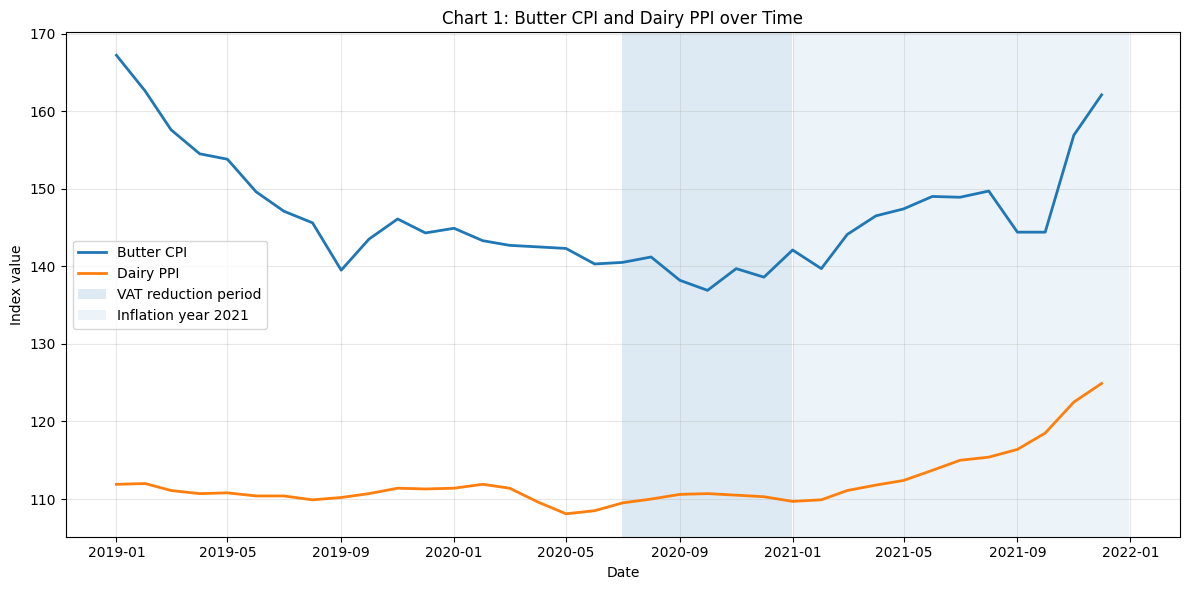

In [25]:
plot_line_chart(analysis_df)


## 11. Visualisierung 2 – Balkendiagramm


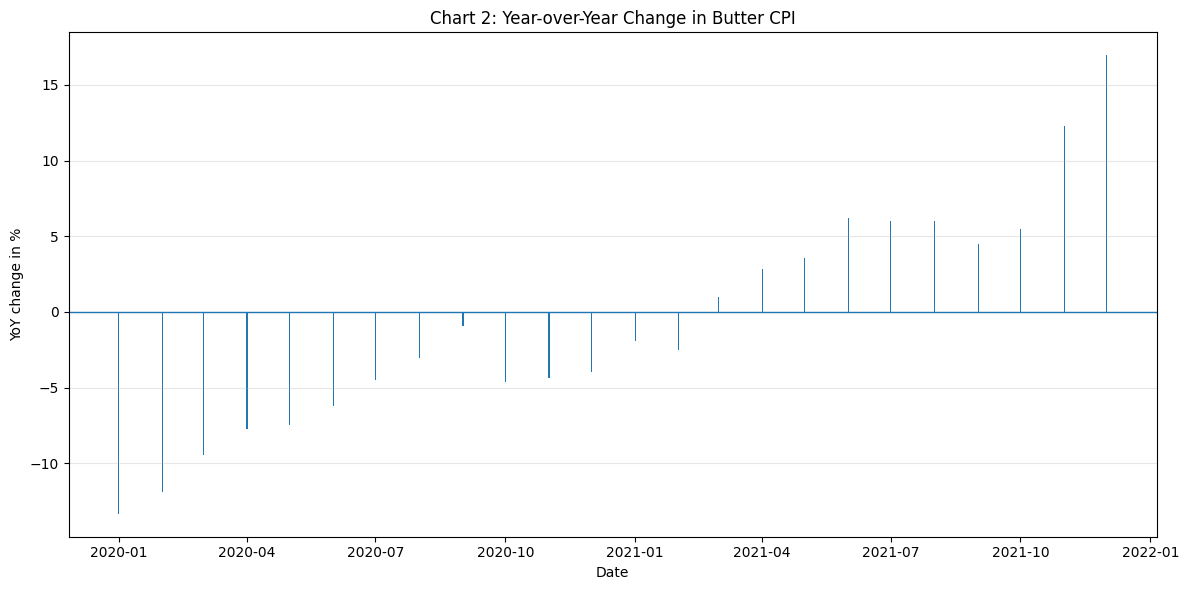

In [26]:
plot_bar_chart(analysis_df)


## 12. Visualisierung 3 – Boxplot


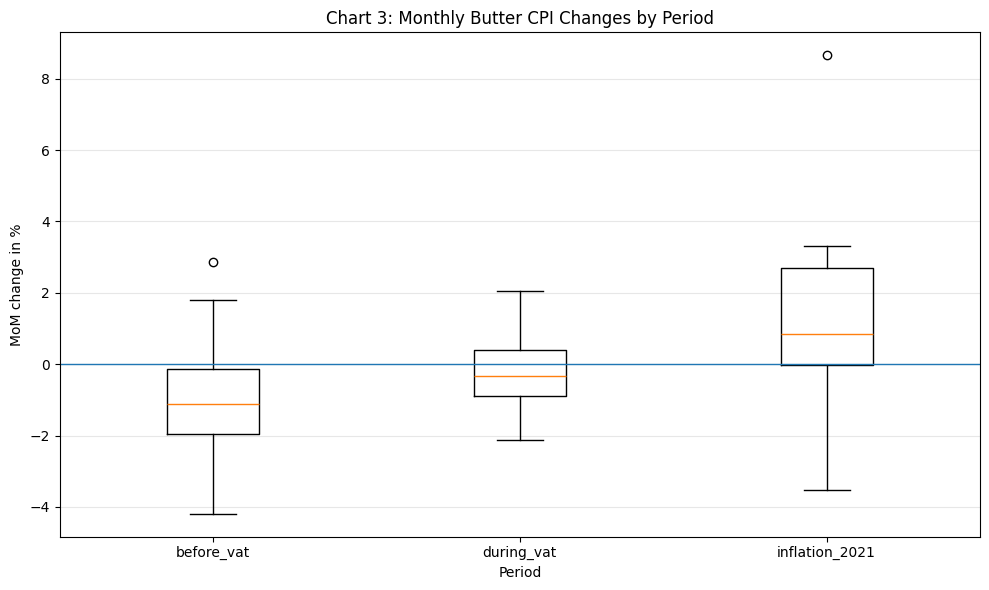

In [27]:
plot_boxplot(analysis_df)


## 13. Visualisierung 4 – Scatterplot


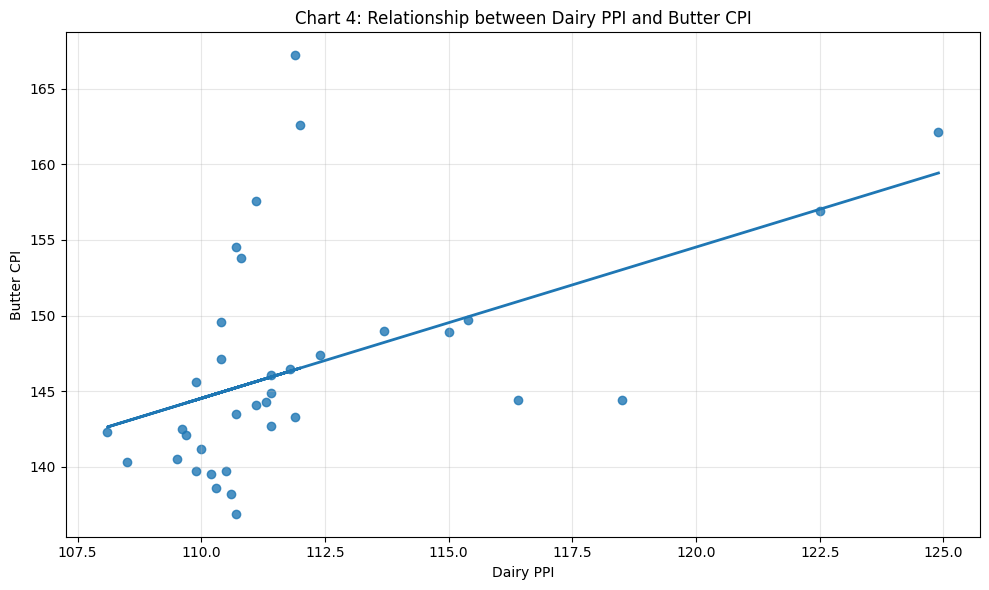

In [28]:
plot_scatter_chart(analysis_df)


In [29]:
import sqlite3
# Achte darauf, wie dein Ergebnis-DataFrame hier heißt (vielleicht auch analysis_df?)
conn = sqlite3.connect('data/inflation_data.db')
analysis_df.to_sql('table_rq4', conn, if_exists='replace', index=False)
conn.close()
